# **FAST SHAPELETS**

Jules CHAPON

Corentin PERNOT

**HOW TO USE THIS NOTEBOOK**

**1.**

In order to use this notebook, you must run the first part, *Introduction*, as it contains all packages and functions used in this notebook.

Functions are split into categories : *Preprocessing*, *SAX Representation*, *Random Projection*, *Selection*, *Fast Shapelets Algorithm*, *Bruteforce Shapelets Algorithm*, *KNN Algorithm*, *Evaluation* and *Visualization*.

For the functions regarding the Fast Shapelets Method, examples of their outputs are displayed to better understand how to use them. The other functions will be used later in the  *Results* part.

**2.**

The second part of the notebook, *Results*, is dedicated to the evaluation of the algorithm and experiments. Each category (*Fast Shapelets Evaluation*, *Comparison with Bruteforce Shapelets*, *Comparison with 1NN*, *DTW*, *Randomness*, *Experiments on Parameters* and *Noise in data*) focus on a specific part and can be run independently as data is re-loaded at the beginning of each part (it takes less than 10 seconds).

One must notice that the categories *Randomness*, *Experiments on Parameters* and *Noise in data* can be quite long (from 10 to 40 minutes per experiment).

**3.**

We hope you enjoy our project !


## **INTRODUCTION**

### **Preliminary steps**

In [1]:
### INSTALL PACKAGES IF NECESSARY

# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install datasets
# !pip install fastdtw
# !pip install scipy
# !pip install scikit-learn
# !pip install tqdm



In [1]:
### PACKAGES

import matplotlib.pyplot as plt
import numpy as np
import time
import seaborn as sns


from collections import defaultdict
from datasets import load_dataset
from fastdtw import fastdtw
from joblib import Parallel, delayed
from scipy.optimize import minimize_scalar
from scipy.stats import norm
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm

c:\Users\jules\anaconda3\envs\py310-ml-ts\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### CONSTANTS

PARAMS = {
    "dimensionality": 16,
    "cardinality": 4,
    "r": 10,
    "k": 10,
    "proba": 0.8,
    "subsequence_length": 32,
}

### **Preprocessing**

In [3]:
### FUNCTIONS


def load_data_from_hf(type: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load a dataset from Hugging Face.

    Args:
        type (str): Whether the dataset is for training or testing.

    Returns:
        tuple[np.ndarray, np.ndarray]: Features, targets.
    """
    data = load_dataset("jules-chapon/ECGFiveDays")
    df = data[type].to_pandas()
    # Select features
    X = df.iloc[:, 1:-1].values
    # Select and clean labels
    y = df.iloc[:, -1].apply(lambda x: x.replace("b", "").replace("'", "")).values
    y = y.astype(int)
    y = y - 1
    print(f"X_{type} shape", X.shape)
    return X, y


def z_normalize_2d(X: np.ndarray) -> np.ndarray:
    """
    Normalize a 2D array using z-score along the rows.

    Args:
        X (np.ndarray): The 2D array to normalize.

    Returns:
        np.ndarray: The normalized array.
    """
    mean = np.mean(X, axis=1, keepdims=True)  # Mean by line
    std = np.std(X, axis=1, keepdims=True)  # Std by line
    std[std == 0] = 1  # To avoid dividing by 0
    return (X - mean) / std


def extract_subsequences(series: np.ndarray, subsequence_length: int) -> np.ndarray:
    """
    Extract subsequences of a given length from a 1D series.

    Args:
        series (np.ndarray): The 1D series from which to extract subsequences.
        subsequence_length (int): The length of the subsequences to extract.

    Returns:
        np.ndarray: The extracted subsequences.
    """
    n_subs = len(series) - subsequence_length + 1  # Number of subsequences
    strides = series.strides[0]
    return np.lib.stride_tricks.as_strided(
        series, shape=(n_subs, subsequence_length), strides=(strides, strides)
    )


def get_occ_per_class(y: np.ndarray) -> dict:
    """
    Count the occurrences of each class in a target array.

    Args:
        y (np.ndarray): The target array.

    Returns:
        dict: A dictionary where keys are class labels and values are the corresponding counts.
    """
    classes = np.unique(y)  # All classes
    return {int(cls): int(np.sum(y == cls)) for cls in classes}


def get_series_per_class(y: np.ndarray) -> dict:
    """
    Get the indices of series for each class in a target array.

    Args:
        y (np.ndarray): The target array.

    Returns:
        dict: A dictionary where keys are class labels and values are lists of indices corresponding to each class.
    """
    dict_series_per_class = defaultdict(list)
    for i, cls in enumerate(y):
        dict_series_per_class[cls].append(i)
    return dict_series_per_class


def add_noise(X: np.ndarray, sigma: float) -> np.ndarray:
    """
    Add Gaussian noise to a 2D array.

    Args:
        X (np.ndarray): The 2D array to which to add noise.
        sigma (float): The standard deviation of the Gaussian noise.

    Returns:
        np.ndarray: The array with added noise.
    """
    noise = np.random.normal(scale=sigma, size=X.shape)  # Gaussian white noise
    return X + noise

In [4]:
### EXAMPLES

X_train, y_train = load_data_from_hf("train")
print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of y_train : {y_train.shape}")
X_train_normalized = z_normalize_2d(X=X_train)
print(f"Mean of a normalized signal : {np.mean(X_train_normalized[0])}")  # Should be 0
print(
    f"Standard deviation of a normalized signal : {np.std(X_train_normalized[0])}"
)  # Should be 1
dict_occ_per_class = get_occ_per_class(y=y_train)
print(f"Class repartition in training : {dict_occ_per_class}")
dict_series_per_class = get_series_per_class(y=y_train)
subsequences = extract_subsequences(
    series=X_train_normalized[0], subsequence_length=PARAMS["subsequence_length"]
)
print(f"Shape of subsequences : {subsequences.shape}")

X_train shape (23, 136)
Shape of X_train : (23, 136)
Shape of y_train : (23,)
Mean of a normalized signal : 6.530723674265627e-17
Standard deviation of a normalized signal : 1.0
Class repartition in training : {0: 14, 1: 9}
Shape of subsequences : (105, 32)


### **SAX Representation**

In [5]:
### FUNCTIONS

ALPHABET = list(
    map(chr, range(97, 97 + 26))
)  # To define letters for the SAX representations


def mean_by_segment(series: np.ndarray, dimensionality: int) -> np.ndarray:
    """
    Calculate the mean of each segment in a series.

    Args:
        series (np.ndarray): The input series.
        dimensionality (int): The number of segments.

    Returns:
        np.ndarray: The means of each segment.
    """
    m = len(series)
    segment_size = m / dimensionality  # Does not have to be an integer
    segments_means = []
    for i in range(dimensionality):
        # Segments might not be of the same size (it can be +/- 1)
        # Because segment_size does not have to be an integer
        start = int(i * segment_size)
        end = int((i + 1) * segment_size)
        segment = series[start:end]
        segments_means.append(np.mean(segment))
    return np.array(segments_means)


def check_dimensionality(m: int, dimensionality: int) -> int:
    """
    Check if dimensionality is not greater than the series length.
    If so, reduce the dimensionality.

    Args:
        m (int): The length of the series.
        dimensionality (int): The desired dimensionality.

    Returns:
        int: The actual dimensionality.
    """
    if m >= dimensionality:
        return dimensionality
    else:
        return m


def get_breakpoints(cardinality: int) -> np.ndarray:
    """
    Get the breakpoints for SAX representation.

    Args:
        cardinality (int): The number of symbols in the SAX alphabet.

    Returns:
        np.ndarray: The breakpoints.
    """
    return norm.ppf(np.linspace(0, 1, cardinality + 1)[1:-1])


def convert_mean_to_sax(mean: float, breakpoints: np.ndarray) -> np.ndarray:
    """
    Convert a mean to SAX representation.

    Args:
        mean (float): The mean value.
        breakpoints (np.ndarray): The breakpoints for SAX representation.

    Returns:
        np.ndarray: The SAX representation.
    """
    sax_idx = np.digitize(mean, breakpoints)
    return ALPHABET[sax_idx]


def convert_segments_to_sax(segments: np.ndarray, breakpoints: np.ndarray) -> str:
    """
    Convert segments to SAX representation.

    Args:
        segments (np.ndarray): The segments.
        breakpoints (np.ndarray): The breakpoints for SAX representation.

    Returns:
        str: The SAX representation.
    """
    sax_segments = [convert_mean_to_sax(mean, breakpoints) for mean in segments]
    return "".join(sax_char for sax_char in sax_segments)


def get_subsequence_sax_representation(
    subsequence: np.ndarray, dimensionality: int, cardinality: int
) -> str:
    """
    Get the SAX representation of a subsequence.

    Args:
        subsequence (np.ndarray): The subsequence.
        dimensionality (int): The dimensionality.
        cardinality (int): The cardinality of the SAX alphabet.

    Returns:
        str: The SAX representation.
    """
    dimensionality = check_dimensionality(subsequence.shape[0], dimensionality)
    breakpoints = get_breakpoints(cardinality)
    segments_means = mean_by_segment(subsequence, dimensionality)
    sax_segments = convert_segments_to_sax(segments_means, breakpoints)
    return sax_segments


def get_series_sax_representations(
    series: np.ndarray, subsequence_length: int, dimensionality: int, cardinality: int
) -> dict[str, np.ndarray]:
    """
    Get the SAX representations of all subsequences in a series.

    Args:
        series (np.ndarray): The series.
        subsequence_length (int): The length of the subsequences.
        dimensionality (int): The dimensionality.
        cardinality (int): The cardinality of the SAX alphabet.

    Returns:
        dict[str, np.ndarray]: The SAX representations.
    """
    dict_representations = {}
    segments = extract_subsequences(
        series=series, subsequence_length=subsequence_length
    )
    dimensionality = check_dimensionality(subsequence_length, dimensionality)
    breakpoints = get_breakpoints(cardinality)
    for segment in segments:
        segments_means = mean_by_segment(segment, dimensionality)
        representation = convert_segments_to_sax(segments_means, breakpoints)
        if representation not in dict_representations:  # Sliding window
            dict_representations[representation] = segment
    return dict_representations


def get_all_sax_representations(
    X: np.ndarray,
    y: np.ndarray,
    params: dict[str, float],
) -> tuple[dict[int, str], dict[int, int], dict[int, int], dict[int, np.ndarray]]:
    """
    Get the SAX representations of all series in a dataset.

    Args:
        X (np.ndarray): The dataset.
        y (np.ndarray): The target labels.
        params (dict[str, float]): The parameters for SAX representation.

    Returns:
        tuple[dict[int, str], dict[int, int], dict[int, int], dict[int, np.ndarray]]: Results.
    """
    map_sax_representations = defaultdict(
        str
    )  # Map candidates IDs with SAX representations
    map_series = defaultdict(int)  # Map candidates IDs with series IDs
    map_classes = defaultdict(int)  # map candidates IDs with classes IDs
    map_subsequences = defaultdict(np.ndarray)  # Map candidates IDs to their values
    idx = 0
    params["dimensionality"] = check_dimensionality(
        params["subsequence_length"], params["dimensionality"]
    )
    breakpoints = get_breakpoints(params["cardinality"])
    for i in range(X.shape[0]):
        series = X[i]
        segments = extract_subsequences(
            series=series, subsequence_length=params["subsequence_length"]
        )
        series_representations = set()
        for segment in segments:
            segments_means = mean_by_segment(segment, params["dimensionality"])
            representation = convert_segments_to_sax(segments_means, breakpoints)
            if representation not in series_representations:  # Sliding window
                series_representations.add(representation)
                map_sax_representations[idx] = representation
                map_series[idx] = i
                map_classes[idx] = int(y[i])
                map_subsequences[idx] = segment
                idx += 1
    return map_sax_representations, map_series, map_classes, map_subsequences

In [6]:
### EXAMPLES

mbs = mean_by_segment(
    series=X_train_normalized[0], dimensionality=PARAMS["dimensionality"]
)
print(f"Number of segments in mbs : {len(mbs)}")
sax_representation = get_subsequence_sax_representation(
    subsequence=X_train_normalized[0],
    dimensionality=PARAMS["dimensionality"],
    cardinality=PARAMS["cardinality"],
)
print(f"SAX representation of the first series : {sax_representation}")

map_sax_representations, map_series, map_classes, map_subsequences = (
    get_all_sax_representations(X=X_train_normalized, y=y_train, params=PARAMS)
)
print(f"Number of candidates after sliding window : {len(map_sax_representations)}")

Number of segments in mbs : 16
SAX representation of the first series : bbbcbcabcdcccbbb
Number of candidates after sliding window : 1915


### **Random Projection**

In [23]:
### FUNCTIONS


def generate_random_mask(dimensionality: int, proba: float = 0.8) -> np.ndarray:
    """Generate a random mask for random projection.

    Args:
        dimensionality (int): The dimensionality of the mask.
        proba (float): The probability of a 1 in the mask. Default is 0.8.

    Returns:
        np.ndarray: A numpy array representing the random mask.
    """
    if dimensionality == 1:
        mask = np.array([1])
    else:
        mask = np.random.choice([0, 1], size=dimensionality, p=[1 - proba, proba])
    return mask


def all_sax_representations_to_array(
    map_sax_representations: dict[int, str],
) -> np.ndarray:
    """Convert all SAX representations to a 2D numpy array.

    Args:
        map_sax_representations (dict[int, str]): A dictionary mapping indices to SAX representations.

    Returns:
        np.ndarray: A 2D numpy array representing all SAX representations.
    """
    values = list(map_sax_representations.values())
    return np.array([list(value) for value in values], dtype=str)


def generate_random_projection(
    array_sax_representations: np.ndarray, mask: np.ndarray
) -> list[str]:
    """Generate a random projection of SAX representations.

    Args:
        array_sax_representations (np.ndarray): A 2D numpy array representing SAX representations.
        mask (np.ndarray): A numpy array representing the random mask.

    Returns:
        list[str]: A list of strings representing the random projection of SAX representations.
    """
    if array_sax_representations.shape[1] != mask.shape[0]:
        raise ValueError("Incompatible dimensions")
    # Get same dimension as array_sax_representations
    mask = mask.reshape(-1, 1)
    mask = np.tile(mask, array_sax_representations.shape[0])
    mask = mask.T
    projection = np.where(mask == 1, array_sax_representations, "")
    return ["".join(row) for row in projection]


def create_collision_tables(
    map_sax_representations: dict[int, str], map_series: dict[int, int]
) -> np.ndarray:
    """Create a collision table for SAX representations and series.

    Args:
        map_sax_representations (dict[int, str]): A dictionary mapping indices to SAX representations.
        map_series (dict[int, int]): A dictionary mapping indices to series.

    Returns:
        np.ndarray: A 2D numpy array representing the collision table.
    """
    n_series = len(set(map_series.values()))
    collision_table = np.zeros(
        (len(map_sax_representations), n_series), dtype=int
    )  # Init table
    return collision_table


def update_collision_table(
    collision_table: np.ndarray, projection: list[str], map_series: dict[int, int]
) -> np.ndarray:
    """Update the collision table based on the random projection.

    Args:
        collision_table (np.ndarray): A 2D numpy array representing the collision table.
        projection (list[str]): A list of strings representing the random projection of SAX representations.
        map_series (dict[int, int]): A dictionary mapping indices to series.

    Returns:
        np.ndarray: A 2D numpy array representing the updated collision table.
    """
    dict_collisions = defaultdict(
        lambda: {"indexes": set(), "series": set()}
    )  # Dict to stock collisions
    for i, projection_sax in enumerate(projection):
        series_id = map_series[i]  # Series ID
        dict_collisions[projection_sax]["indexes"].add(
            i
        )  # All candidates IDs with collisions
        dict_collisions[projection_sax]["series"].add(
            series_id
        )  # All series IDs with collisions
    for sax in dict_collisions.keys():
        collision_indexes = dict_collisions[sax]["indexes"]
        collision_series = dict_collisions[sax]["series"]
        for idx in collision_indexes:
            for series in collision_series:
                collision_table[idx][series] += 1  # Add number of collisions
    return collision_table


def get_array_occ_by_class(dict_occ_by_class: dict[int, int]) -> np.ndarray:
    """Get the number of occurrences per class as a numpy array.

    Args:
        dict_occ_by_class (dict[int, int]): A dictionary mapping class indices to the number of occurrences.

    Returns:
        np.ndarray: A numpy array representing the number of occurrences per class.
    """
    array_occ_by_class = np.array(
        [dict_occ_by_class[i] for i in range(len(dict_occ_by_class))]
    )
    return array_occ_by_class


def transpose_collision_table_to_classes(
    collision_table: np.ndarray, dict_series_per_class: dict[int, list[int]]
) -> np.ndarray:
    """Transpose the collision table to classes.

    Args:
        collision_table (np.ndarray): A 2D numpy array representing the collision table.
        dict_series_per_class (dict[int, list[int]]): A dictionary mapping class indices to series indices.

    Returns:
        np.ndarray: A 2D numpy array representing the transposed collision table.
    """
    close_table = np.zeros(
        (collision_table.shape[0], len(dict_series_per_class))
    )  # Init table
    for class_id, indices in dict_series_per_class.items():
        close_table[:, class_id] = np.sum(
            collision_table[:, indices], axis=1
        )  # Sum by class
    return close_table


def compute_distinguish_power(
    close_table: np.ndarray, r: int, array_occ_by_class: np.ndarray
) -> np.ndarray:
    """Compute the distinguish power for each SAX representation.

    Args:
        close_table (np.ndarray): A 2D numpy array representing the transposed collision table.
        r (int): The number of random projections.
        array_occ_by_class (np.ndarray): A numpy array representing the number of occurrences per class.

    Returns:
        np.ndarray: A numpy array representing the distinguish power for each SAX representation.
    """
    array_occ = r * array_occ_by_class  # Maximum of collisions with each class
    full_table = np.tile(
        array_occ, (close_table.shape[0], 1)
    )  # Table if full collisions
    far_table = full_table - close_table  # Table counting # times without collision
    distinguish_table = np.abs(close_table - far_table)
    distinguish_power = np.sum(distinguish_table, axis=1)
    return distinguish_power


def get_top_k_candidates_indexes(distinguish_power: np.ndarray, k: int) -> list[int]:
    """Get the top k candidates based on distinguish power.

    Args:
        distinguish_power (np.ndarray): A numpy array representing the distinguish power for each SAX representation.
        k (int): The number of top candidates to retrieve.

    Returns:
        list[int]: A list of integers representing the indices of the top k candidates.
    """
    top_k_indices = np.argpartition(distinguish_power, -k)[-k:]
    return top_k_indices[::-1].tolist()


def get_candidates_subsequences(
    candidates_indexes: list[int], map_subsequences: dict[int, np.ndarray]
) -> np.ndarray:
    """Get the subsequences of the top k candidates.

    Args:
        candidates_indexes (list[int]): A list of integers representing the indices of the top k candidates.
        map_subsequences (dict[int, np.ndarray]): A dictionary mapping indices to subsequences.

    Returns:
        np.ndarray: A 2D numpy array representing the subsequences of the top k candidates.
    """
    candidates_subsequences = np.array(
        [map_subsequences[idx_candidate] for idx_candidate in candidates_indexes]
    )
    return candidates_subsequences


def compute_candidates(
    params: dict[str, float],
    map_sax_representations: dict[int, str],
    map_series: dict[int, int],
    map_subsequences: dict[int, np.ndarray],
    dict_occ_per_class: dict[int, int],
    dict_series_per_class: dict[int, list[int]],
) -> np.ndarray:
    """Compute the top k candidates based on distinguish power.

    Args:
        params (dict[str, float]): A dictionary containing the parameters for the computation.
        map_sax_representations (dict[int, str]): A dictionary mapping indices to SAX representations.
        map_series (dict[int, int]): A dictionary mapping indices to series.
        map_subsequences (dict[int, np.ndarray]): A dictionary mapping indices to subsequences.
        dict_occ_per_class (dict[int, int]): A dictionary mapping class indices to the number of occurrences.
        dict_series_per_class (dict[int, list[int]]): A dictionary mapping class indices to series indices.

    Returns:
        np.ndarray: A 2D numpy array representing the subsequences of the top k candidates.
    """
    array_sax_representations = all_sax_representations_to_array(
        map_sax_representations=map_sax_representations
    )
    collision_table = create_collision_tables(
        map_sax_representations=map_sax_representations, map_series=map_series
    )  # init table
    for _ in range(params["r"]):
        mask = generate_random_mask(
            dimensionality=params["dimensionality"], proba=params["proba"]
        )  # Random mask
        projection = generate_random_projection(
            array_sax_representations=array_sax_representations, mask=mask
        )  # Random projection
        collision_table = update_collision_table(
            collision_table=collision_table,
            projection=projection,
            map_series=map_series,
        )  # Iterations
    array_occ_by_class = get_array_occ_by_class(dict_occ_by_class=dict_occ_per_class)
    close_table = transpose_collision_table_to_classes(
        collision_table=collision_table, dict_series_per_class=dict_series_per_class
    )  # Collisions by class
    distinguish_power = compute_distinguish_power(
        close_table=close_table, r=params["r"], array_occ_by_class=array_occ_by_class
    )
    candidates_indexes = get_top_k_candidates_indexes(
        distinguish_power=distinguish_power, k=params["k"]
    )  # Find best k candidates
    candidates = get_candidates_subsequences(
        candidates_indexes=candidates_indexes, map_subsequences=map_subsequences
    )  # Candidates signals
    return candidates

In [24]:
### EXAMPLES

mask = generate_random_mask(dimensionality=PARAMS["dimensionality"])
print(f"Random mask : {mask}")
collision_table = create_collision_tables(
    map_sax_representations=map_sax_representations, map_series=map_series
)
print(f"Shape of the collision table : {collision_table.shape}")
candidates = compute_candidates(
    params=PARAMS,
    map_sax_representations=map_sax_representations,
    map_series=map_series,
    map_subsequences=map_subsequences,
    dict_occ_per_class=dict_occ_per_class,
    dict_series_per_class=dict_series_per_class,
)
print(f"Number of candidates after the random projection : {candidates.shape[0]}")

Random mask : [1 1 1 1 1 0 1 1 1 1 0 0 1 1 0 1]
Shape of the collision table : (1915, 23)
Number of candidates after the random projection : 10


### **Selection**

In [25]:
### FUNCTIONS


def euclidean_distance(series_1: np.ndarray, series_2: np.ndarray) -> float:
    """
    Compute the Euclidean distance between two series.

    Args:
        series_1 (np.ndarray): The first series.
        series_2 (np.ndarray): The second series.

    Returns:
        float: The Euclidean distance between the two series.
    """
    return float((1 / series_1.shape[0]) * np.linalg.norm(series_1 - series_2))


def dtw_distance(series_1: np.ndarray, series_2: np.ndarray) -> float:
    """
    Compute the DTW distance between two series.

    Args:
        series_1 (np.ndarray): The first series.
        series_2 (np.ndarray): The second series.

    Returns:
        float: The DTW distance between the two series.
    """
    distance, _ = fastdtw(series_1, series_2, dist=2)
    return float(distance)


def distance_to_series(
    target: np.ndarray, series: np.ndarray, distance_method: str = "euclidean"
) -> float:
    """
    Compute the distance between a target series and a series.

    Args:
        target (np.ndarray): The target series.
        series (np.ndarray): The series to compare with the target.
        distance_method (str, optional): The method to compute the distance. Defaults to "euclidean".

    Returns:
        float: The distance between the target series and the series.
    """
    subsequences = extract_subsequences(
        series=series, subsequence_length=target.shape[0]
    )
    if distance_method == "euclidean":
        distances = np.array(
            [euclidean_distance(target, subsequence) for subsequence in subsequences]
        )
    elif distance_method == "dtw":
        distances = np.array(
            [dtw_distance(target, subsequence) for subsequence in subsequences]
        )
    else:
        raise ValueError("Invalid distance method. Choose either 'euclidean' or 'dtw'.")
    return float(np.min(distances))


def distance_to_all_series(
    target: np.ndarray, X: np.ndarray, distance_method: str = "euclidean"
) -> np.ndarray:
    """
    Compute the distance between a target series and all series in a dataset.

    Args:
        target (np.ndarray): The target series.
        X (np.ndarray): The dataset of series.
        distance_method (str, optional): The method to compute the distance. Defaults to "euclidean".

    Returns:
        np.ndarray: The distances between the target series and all series in the dataset.
    """
    if len(X.shape) > 1:
        return np.array(
            [
                distance_to_series(
                    target=target, series=series, distance_method=distance_method
                )
                for series in X
            ]
        )
    else:
        return np.array(
            [
                distance_to_series(
                    target=target, series=X, distance_method=distance_method
                )
            ]
        )  # If X contains only 1 series


def split(distances: np.ndarray, threshold: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Split the indices of distances based on a threshold.

    Args:
        distances (np.ndarray): The distances.
        threshold (float): The threshold to split the indices.

    Returns:
        tuple: The indices of distances below the threshold and the indices of distances above the threshold.
    """
    below_threshold_indices = distances < threshold
    above_threshold_indices = distances >= threshold
    return below_threshold_indices, above_threshold_indices


def compute_entropy(dict_occ_by_class: dict[int, int]) -> float:
    """
    Compute the entropy of a dictionary of occurrences by class.

    Args:
        dict_occ_by_class (dict[int, int]): The dictionary of occurrences by class.

    Returns:
        float: The entropy of the dictionary.
    """
    total_occurrences = sum(dict_occ_by_class.values())
    probabilities = [occ / total_occurrences for occ in dict_occ_by_class.values()]
    return -float(np.sum(probabilities * np.log2(probabilities)))


def compute_information_gain(
    y: np.ndarray, below_indices: np.ndarray, above_indices: np.ndarray
) -> float:
    """
    Compute the information gain of splitting a dataset based on a threshold.

    Args:
        y (np.ndarray): The target variable.
        below_indices (np.ndarray): The indices of the dataset below the threshold.
        above_indices (np.ndarray): The indices of the dataset above the threshold.

    Returns:
        float: The information gain of the split.
    """
    y_below = y[below_indices]
    y_above = y[above_indices]
    n = y.shape[0]
    n_below = y_below.shape[0]
    n_above = y_above.shape[0]
    if n_below == 0 or n_above == 0:
        return 0
    entropy_total = compute_entropy(get_occ_per_class(y=y))
    entropy_below = compute_entropy(get_occ_per_class(y=y_below))
    entropy_above = compute_entropy(get_occ_per_class(y=y_above))
    return entropy_total - (n_below / n) * entropy_below - (n_above / n) * entropy_above


def function_to_minimize(
    threshold: float, distances: np.ndarray, y: np.ndarray
) -> float:
    """
    Function to minimize for finding the threshold that maximizes information gain.

    Args:
        threshold (float): The threshold to minimize.
        distances (np.ndarray): The distances.
        y (np.ndarray): The target variable.

    Returns:
        float: The negative information gain of the split.
    """
    below_indices, above_indices = split(distances=distances, threshold=threshold)
    return -compute_information_gain(
        y=y, below_indices=below_indices, above_indices=above_indices
    )  # Maximizing f = Minimizing -f


def maximize_information_gain(distances: np.ndarray, y: np.ndarray) -> float:
    """
    Find the threshold that maximizes information gain.

    Args:
        distances (np.ndarray): The distances.
        y (np.ndarray): The target variable.

    Returns:
        float: The threshold that maximizes information gain.
    """
    bounds = (0, distances.max())
    result = minimize_scalar(
        function_to_minimize,
        args=(distances, y),
        bounds=bounds,
        method="bounded",
    )
    return float(result.x)


def compute_gap(
    distances: np.ndarray, below_indices: np.ndarray, above_indices: np.ndarray
) -> float:
    """
    Compute the gap between the average distances of two sets of indices.

    Args:
        distances (np.ndarray): The distances.
        below_indices (np.ndarray): The indices of the dataset below the threshold.
        above_indices (np.ndarray): The indices of the dataset above the threshold.

    Returns:
        float: The gap between the average distances of the two sets.
    """
    n_below = below_indices.shape[0]
    n_above = above_indices.shape[0]
    if n_below == 0 or n_above == 0:
        return 0
    below_distances = distances[below_indices]
    above_distances = distances[above_indices]
    return float(np.abs(np.mean(above_distances) - np.mean(below_distances)))


def select_best_candidate(
    array_candidates: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    params_best_candidate: dict[str, float],
    distance_method: str = "euclidean",
) -> tuple[int, int | float | np.ndarray]:
    """
    Select the best candidate from an array of candidates based on maximizing information gain and minimizing gap.

    Args:
        array_candidates (np.ndarray): The array of candidates.
        X (np.ndarray): The dataset of series.
        y (np.ndarray): The target variable.
        params_best_candidate (dict[str, float]): The parameters of the best candidate found so far.
        distance_method (str, optional): The method to compute the distance. Defaults to "euclidean".

    Returns:
        tuple: The index of the best candidate in the array, the best candidate, the threshold, and the information gain and gap.
    """
    for candidate in array_candidates:
        distances = distance_to_all_series(
            target=candidate, X=X, distance_method=distance_method
        )  # Distance to each series
        threshold = maximize_information_gain(
            distances=distances, y=y
        )  # Optimal threshold
        below_indices, above_indices = split(distances=distances, threshold=threshold)
        info_gain = compute_information_gain(
            y=y, below_indices=below_indices, above_indices=above_indices
        )  # Information gain
        gap = compute_gap(
            distances=distances,
            below_indices=below_indices,
            above_indices=above_indices,
        )  # Gap
        if info_gain > params_best_candidate["info_gain"] or (
            info_gain == params_best_candidate["info_gain"]
            and gap > params_best_candidate["gap"]
        ):  # If better than the current best one
            params_best_candidate["info_gain"] = info_gain
            params_best_candidate["gap"] = gap
            params_best_candidate["shapelet"] = candidate
            params_best_candidate["threshold"] = threshold
    return params_best_candidate

In [26]:
### EXAMPLES


distance_1 = distance_to_series(target=subsequences[0], series=X_train_normalized[0])
print(f"Distance of a subsequence to its series : {distance_1:.4f}")
distance_2 = distance_to_series(target=subsequences[0], series=X_train_normalized[1])
print(f"Distance of a subsequence to its series : {distance_2:.4f}")
distances = distance_to_all_series(target=subsequences[0], X=X_train_normalized)
print(f"Number of distances : {distances.shape[0]}")
below_threshold_indices, above_threshold_indices = split(
    distances=distances, threshold=0.05
)
info_gain = compute_information_gain(
    y=y_train,
    below_indices=below_threshold_indices,
    above_indices=above_threshold_indices,
)

print(f"Information gain of the given split : {info_gain:.4f}")
gap = compute_gap(
    distances=distances,
    below_indices=below_threshold_indices,
    above_indices=above_threshold_indices,
)

print(f"Gap of the given split : {gap:.4f}")
params_best_candidate = {"info_gain": 0.0, "gap": 0.0}

params_best_candidate = select_best_candidate(
    array_candidates=candidates,
    X=X_train_normalized,
    y=y_train,
    params_best_candidate=params_best_candidate,
)
print(
    f"Information gain of the best candidate of the given subsequence length : {params_best_candidate['info_gain']:.4f}"
)
print(
    f"Gap of the best candidate of the given subsequence length : {params_best_candidate['gap']:.4f}"
)

Distance of a subsequence to its series : 0.0000
Distance of a subsequence to its series : 0.0065
Number of distances : 23
Information gain of the given split : 0.0611
Gap of the given split : 0.0460
Information gain of the best candidate of the given subsequence length : 0.1272
Gap of the best candidate of the given subsequence length : 0.0905


### **Fast Shapelets Algorithm**

In [27]:
### FUNCTIONS


def compute_fast_shapelets(
    X_train: np.ndarray, y_train: np.ndarray, params: dict[str, float]
) -> dict:
    """
    Compute fast shapelets using random projection and SAX.

    Args:
        X_train (np.ndarray): The training data features.
        y_train (np.ndarray): The training data labels.
        params (dict[str, float]): The parameters for computing fast shapelets.

    Returns:
        dict: The parameters of the best candidate shapelet.
    """
    X_train = z_normalize_2d(X=X_train)
    dict_occ_per_class = get_occ_per_class(y=y_train)
    dict_series_per_class = get_series_per_class(y=y_train)
    distance_method = (
        params["distance_method"] if "distance_method" in params else "euclidean"
    )
    params_best_candidate = {"info_gain": 0.0, "gap": 0.0}
    current_params = params.copy()
    for subsequence_length in range(X_train.shape[1]):
        current_params["subsequence_length"] = subsequence_length + 1
        current_params["dimensionality"] = params["dimensionality"]
        map_sax_representations, map_series, map_classes, map_subsequences = (
            get_all_sax_representations(X=X_train, y=y_train, params=current_params)
        )
        candidates = compute_candidates(
            params=current_params,
            map_sax_representations=map_sax_representations,
            map_series=map_series,
            map_subsequences=map_subsequences,
            dict_occ_per_class=dict_occ_per_class,
            dict_series_per_class=dict_series_per_class,
            distance_method=distance_method,
        )
        params_best_candidate = select_best_candidate(
            array_candidates=candidates,
            X=X_train,
            y=y_train,
            params_best_candidate=params_best_candidate,
        )
    return params_best_candidate


def function_to_parallelize(
    subsequence_length: int,
    X_train: np.ndarray,
    y_train: np.ndarray,
    current_params: dict,
    dict_occ_per_class: dict,
    dict_series_per_class: dict,
    params: dict[str, int | float],
    distance_method: str = "euclidean",
) -> dict:
    """
    Function to parallelize the computation of fast shapelets.

    Args:
        subsequence_length (int): The length of the subsequence.
        X_train (np.ndarray): The training data features.
        y_train (np.ndarray): The training data labels.
        current_params (dict): The current parameters for computing fast shapelets.
        dict_occ_per_class (dict): The occurrence per class.
        dict_series_per_class (dict): The series per class.
        params (dict[str, int | float]): The parameters for computing fast shapelets.
        distance_method (str | Optional): The distance method to use for computing distances. Defaults to "euclidean".

    Returns:
        dict: The parameters of the best candidate shapelet for the current subsequence length.
    """
    current_params["subsequence_length"] = subsequence_length + 1
    current_params["dimensionality"] = params["dimensionality"]
    map_sax_representations, map_series, map_classes, map_subsequences = (
        get_all_sax_representations(X=X_train, y=y_train, params=current_params)
    )
    candidates = compute_candidates(
        params=current_params,
        map_sax_representations=map_sax_representations,
        map_series=map_series,
        map_subsequences=map_subsequences,
        dict_occ_per_class=dict_occ_per_class,
        dict_series_per_class=dict_series_per_class,
    )
    params_best_candidate = {"info_gain": 0.0, "gap": 0.0}  # Init values
    params_best_candidate = select_best_candidate(
        array_candidates=candidates,
        X=X_train,
        y=y_train,
        params_best_candidate=params_best_candidate,
        distance_method=distance_method,
    )
    return params_best_candidate


def compute_fast_shapelets_parallelized(
    X_train: np.ndarray, y_train: np.ndarray, params: dict[str, int | float]
) -> dict:
    """
    Compute fast shapelets using random projection and SAX in parallel.

    Args:
        X_train (np.ndarray): The training data features.
        y_train (np.ndarray): The training data labels.
        params (dict[str, int | float]): The parameters for computing fast shapelets.

    Returns:
        dict: The parameters of the best candidate shapelet.
    """
    X_train = z_normalize_2d(X=X_train)
    dict_occ_per_class = get_occ_per_class(y=y_train)
    dict_series_per_class = get_series_per_class(y=y_train)
    distance_method = (
        params["distance_method"] if "distance_method" in params else "euclidean"
    )  # Init distance method
    results = Parallel(n_jobs=-1)(
        delayed(function_to_parallelize)(
            subsequence_length=subsequence_length,
            X_train=X_train,
            y_train=y_train,
            current_params=params.copy(),
            dict_occ_per_class=dict_occ_per_class,
            dict_series_per_class=dict_series_per_class,
            params=params,
            distance_method=distance_method,
        )
        for subsequence_length in range(X_train.shape[1])
    )
    return max(
        results, key=lambda d: (d["info_gain"], d["gap"])
    )  # Select shapelet that maximizes info_gain and gap

In [28]:
### EXAMPLES

params_fs = compute_fast_shapelets_parallelized(
    X_train=X_train_normalized, y_train=y_train, params=PARAMS
)
print(f"Length of the selected shapelet : {params_fs['shapelet'].shape[0]}")
print(f"Information gain of the selected shapelet : {params_fs['info_gain']:.4f}")
print(f"Gap of the selected shapelet : {params_fs['gap']:.4f}")

Length of the selected shapelet : 48
Information gain of the selected shapelet : 0.9656
Gap of the selected shapelet : 0.0412


### **Bruteforce Shapelets Algorithm**

In [29]:
### FUNCTIONS


def get_candidates(X_train: np.ndarray, subsequence_length: int) -> np.ndarray:
    """
    Get all candidates of a given length.

    Args:
        X_train (np.ndarray): Train data.
        subsequence_length (int): Length to look for.

    Returns:
        np.ndarray: Candidates of selected length.
    """
    list_candidates = []
    for i in range(X_train.shape[0]):
        series = X_train[i]
        candidates = extract_subsequences(
            series=series, subsequence_length=subsequence_length
        )
        list_candidates.append(candidates)
    return np.concatenate(list_candidates)


def compute_bf_shapelets(
    X_train: np.ndarray,
    y_train: np.ndarray,
    subsequence_length: int,
    distance_method: str = "euclidean",
) -> dict:
    """
    Compute bruteforce shapelets algorithm.

    Args:
        X_train (np.ndarray): Train data.
        y_train (np.ndarray): Train labels.
        subsequence_length (int): Length of shapelet to look for.
        distance_method (str, optional): Method to calculate distances. Defaults to "euclidean".

    Returns:
        dict: Parameters of the selected shapelet.
    """
    X_train = z_normalize_2d(X=X_train)
    params_best_candidate = {"info_gain": 0.0, "gap": 0.0}
    candidates = get_candidates(X_train=X_train, subsequence_length=subsequence_length)
    params_best_candidate = select_best_candidate(
        array_candidates=candidates,
        X=X_train,
        y=y_train,
        params_best_candidate=params_best_candidate,
        distance_method=distance_method,
    )
    return params_best_candidate

### **KNN Algorithm**

In [30]:
### FUNCTIONS


def knn_train(
    X_train: np.ndarray,
    y_train: np.ndarray,
    distance_method: str = "euclidean",
    k: int = 1,
) -> KNeighborsClassifier:
    """
    Train a K-Nearest Neighbors classifier.

    Args:
        X_train (np.ndarray): The training data features.
        y_train (np.ndarray): The training data labels.
        distance_method (str): The distance metric to use. Choices are 'euclidean' and 'dtw'. Default is 'euclidean'.
        k (int): The number of neighbors to consider. Default is 1.

    Returns:
        KNeighborsClassifier: The trained KNN classifier.
    """
    if distance_method == "euclidean":
        knn = KNeighborsClassifier(n_neighbors=k)
    elif distance_method == "dtw":
        knn = KNeighborsClassifier(n_neighbors=k, metric=dtw_distance)
    else:
        raise ValueError("Invalid distance method. Choose either 'euclidean' or 'dtw'.")
    knn.fit(X_train, y_train)
    return knn


def knn_predict(knn: KNeighborsClassifier, X_test: np.ndarray) -> np.ndarray:
    """
    Predict the labels for the test data using a trained KNN classifier.

    Args:
        knn (KNeighborsClassifier): The trained KNN classifier.
        X_test (np.ndarray): The test data features.

    Returns:
        np.ndarray: The predicted labels for the test data.
    """
    return knn.predict(X_test)

### **Evaluation Functions**

In [31]:
### FUNCTIONS


def find_shapelet_position(
    series: np.ndarray, shapelet_params: dict[str, int | float | np.ndarray]
) -> int:
    """
    Find the position of the shapelet in the series.

    Args:
        series (np.ndarray): The series where to find the shapelet.
        shapelet_params (dict): The parameters of the shapelet.

    Returns:
        int: The position of the shapelet in the series.
    """
    subsequences = extract_subsequences(
        series=series, subsequence_length=shapelet_params["shapelet"].shape[0]
    )  # Subsequences of the signal
    distances = np.array(
        [
            euclidean_distance(shapelet_params["shapelet"], subsequence)
            for subsequence in subsequences
        ]
    )  # Distance to all subsequence
    return np.argmin(distances)


def find_classification_criterion(
    X_train: np.ndarray,
    y_train: np.ndarray,
    shapelet_params: dict[str, int | float | np.ndarray],
) -> None:
    """
    Find the classification criterion for the shapelet.

    Args:
        X_train (np.ndarray): The training data.
        y_train (np.ndarray): The labels of the training data.
        shapelet_params (dict): The parameters of the shapelet.
    """
    classes = np.unique(y_train)
    distances = distance_to_all_series(target=shapelet_params["shapelet"], X=X_train)
    below_threshold_indices, above_threshold_indices = split(
        distances=distances, threshold=shapelet_params["threshold"]
    )  # Distances to all training series
    y_below = y_train[below_threshold_indices]
    y_above = y_train[above_threshold_indices]
    class_count = {
        "below": {int(c): int(np.sum([y_below == c])) for c in classes},
        "above": {int(c): int(np.sum([y_above == c])) for c in classes},
    }
    class_below = max(
        class_count["below"], key=class_count["below"].get
    )  # Dominant class below threshold
    class_above = max(
        class_count["above"], key=class_count["above"].get
    )  # Dominant class above threshold
    if class_below != class_above:
        shapelet_params["class_below"] = (
            class_below  # Class to predict if distance < threshold
        )
        shapelet_params["class_above"] = (
            class_above  # Class to predict if distance >= threshold
        )
    else:
        raise ValueError("This shapelet cannot split classes correctly.")


def predict(
    X_test: np.ndarray,
    shapelet_params: dict[str, int | float | np.ndarray],
) -> np.ndarray:
    """
    Predict the labels of the test data using the shapelet.

    Args:
        X_test (np.ndarray): The test data.
        shapelet_params (dict): The parameters of the shapelet.

    Returns:
        np.ndarray: The predicted labels of the test data.
    """
    distances = distance_to_all_series(
        target=shapelet_params["shapelet"], X=X_test
    )  # Distances to shapelet
    y_pred = np.where(
        distances < shapelet_params["threshold"],
        shapelet_params["class_below"],
        shapelet_params["class_above"],
    )  # Predictions
    return y_pred


def compute_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Compute the accuracy of the predictions.

    Args:
        y_true (np.ndarray): The true labels.
        y_pred (np.ndarray): The predicted labels.

    Returns:
        float: The accuracy of the predictions.
    """
    return accuracy_score(y_true=y_true, y_pred=y_pred)


def run_experiments(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    params: dict[str, float],
    param_to_test: str,
    values: np.ndarray,
    nb_times: int = 10,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run experiments to find the impact of a parameter on the accuracy.

    Args:
        X_train (np.ndarray): The training data.
        y_train (np.ndarray): The labels of the training data.
        X_test (np.ndarray): The test data.
        y_test (np.ndarray): The labels of the test data.
        params (dict): The parameters of the shapelet.
        param_to_test (str): The parameter to test.
        values (np.ndarray): The values to test for the parameter.
        nb_times (int): The number of times to repeat the experiment.

    Returns:
        tuple: The values tested, the mean accuracies, and the standard deviations of the accuracies.
    """
    accuracies = []
    times = []
    for value in tqdm(values):
        params[param_to_test] = value
        accuracies_temp = []
        times_temp = []
        for _ in range(nb_times):
            start_time = time.time()
            shapelet_params = compute_fast_shapelets_parallelized(
                X_train=X_train, y_train=y_train, params=params
            )  # training
            end_time = time.time()
            find_classification_criterion(
                X_train=X_train, y_train=y_train, shapelet_params=shapelet_params
            )
            y_pred = predict(
                X_test=X_test, shapelet_params=shapelet_params
            )  # Prediction
            accuracy = compute_accuracy(y_true=y_test, y_pred=y_pred)  # Accuracy
            accuracies_temp.append(accuracy)
            times_temp.append(end_time - start_time)
        accuracies.append(
            (
                np.mean(accuracies_temp),
                np.std(accuracies_temp, ddof=1) / np.sqrt(len(accuracies_temp)),
            )
        )
        times.append(
            (
                np.mean(times_temp),
                np.std(times_temp, ddof=1) / np.sqrt(len(times_temp)),
            )
        )
    return values, np.array(accuracies), np.array(times)


def compute_randomness(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    params: dict[str, int | float],
    nb_times: int = 10,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute the randomness of the shapelet classifier.

    Args:
        X_train (np.ndarray): The training data.
        y_train (np.ndarray): The labels of the training data.
        X_test (np.ndarray): The test data.
        y_test (np.ndarray): The labels of the test data.
        params (dict): The parameters of the shapelet.
        nb_times (int): The number of times to repeat the experiment.

    Returns:
        tuple: The indices tested, the mean train accuracies, and the mean test accuracies.
    """
    train_accuracies = np.zeros(nb_times)
    test_accuracies = np.zeros(nb_times)
    for i in range(nb_times):
        shapelet_params = compute_fast_shapelets_parallelized(
            X_train=X_train, y_train=y_train, params=params
        )  # Training
        find_classification_criterion(
            X_train=X_train, y_train=y_train, shapelet_params=shapelet_params
        )
        y_pred_train = predict(
            X_test=X_train, shapelet_params=shapelet_params
        )  # Prediction on train
        y_pred_test = predict(
            X_test=X_test, shapelet_params=shapelet_params
        )  # Prediction on test
        train_accuracies[i] = compute_accuracy(
            y_true=y_train, y_pred=y_pred_train
        )  # Accuracy on train
        test_accuracies[i] = compute_accuracy(
            y_true=y_test, y_pred=y_pred_test
        )  # Accuracy on test
    return np.array(range(nb_times)), train_accuracies, test_accuracies


def compute_noise_accuracy(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    params: dict[str, float],
    sigmas: np.ndarray,
    noise: str,
    nb_times: int = 10,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute the accuracy of the shapelet classifier in the presence of noise.

    Args:
        X_train (np.ndarray): The training data.
        y_train (np.ndarray): The labels of the training data.
        X_test (np.ndarray): The test data.
        y_test (np.ndarray): The labels of the test data.
        params (dict): The parameters of the shapelet.
        sigmas (np.ndarray): The noise levels to test.
        noise (str): The type of noise to add.
        nb_times (int): The number of times to repeat the experiment.

    Returns:
        tuple: The noise levels tested, the mean KNN accuracies, and the mean shapelet accuracies.
    """
    knn_accuracies = []
    shapelet_accuracies = []
    for sigma in tqdm(sigmas):
        knn_temp = []
        shapelet_temp = []
        for _ in range(nb_times):
            # Data
            if noise == "both":
                X_train_noisy = add_noise(X=X_train, sigma=sigma)
                X_train_final = z_normalize_2d(X=X_train_noisy)
            else:
                X_train_final = z_normalize_2d(X=X_train)
            X_test_noisy = add_noise(X=X_test, sigma=sigma)
            X_test_final = z_normalize_2d(X=X_test_noisy)
            # KNN
            knn = knn_train(X_train=X_train_final, y_train=y_train)  # Training
            knn_pred = knn_predict(knn=knn, X_test=X_test_final)  # Prediction
            knn_accuracy = compute_accuracy(y_true=y_test, y_pred=knn_pred)  # Accuracy
            knn_temp.append(knn_accuracy)
            # Shapelets
            shapelet_params = compute_fast_shapelets_parallelized(
                X_train=X_train_final, y_train=y_train, params=params
            )  # Training
            find_classification_criterion(
                X_train=X_train_final, y_train=y_train, shapelet_params=shapelet_params
            )
            shapelet_pred = predict(
                X_test=X_test_final, shapelet_params=shapelet_params
            )  # Prediction
            shapelet_accuracy = compute_accuracy(
                y_true=y_test, y_pred=shapelet_pred
            )  # Accuracy
            shapelet_temp.append(shapelet_accuracy)
        knn_accuracies.append(
            (
                np.mean(knn_temp),
                np.std(knn_temp, ddof=1) / np.sqrt(len(knn_temp)),
            )
        )
        shapelet_accuracies.append(
            (
                np.mean(shapelet_temp),
                np.std(shapelet_temp, ddof=1) / np.sqrt(len(shapelet_temp)),
            )
        )
    return sigmas, np.array(knn_accuracies), np.array(shapelet_accuracies)

### **Visualization functions**

In [32]:
### FUNCTIONS


def plot_shapelet(shapelet_params: dict[str, int | float | np.ndarray]) -> None:
    """
    Plots the selected shapelet.

    Args:
        shapelet_params (dict): A dictionary containing the shapelet parameters.
    """
    plt.plot(shapelet_params["shapelet"], c="red", linewidth=2)
    plt.xlabel("Time")
    plt.ylabel("Signal value")
    plt.grid(visible=True, which="major", axis="y")
    plt.title("Selected shapelet")
    plt.xlim((-5, 90))
    plt.ylim((-6, 3))
    plt.show()


def plot_series_with_shapelet(
    X: np.ndarray,
    y: np.ndarray,
    shapelet_params: dict[str, int | float | np.ndarray],
    index: int,
) -> None:
    """
    Plots a series with the selected shapelet.

    Args:
        X (np.ndarray): The input series.
        y (np.ndarray): The true classes of the series.
        shapelet_params (dict): A dictionary containing the shapelet parameters.
        index (int): The index of the series to plot.
    """
    series = X[index]
    true_class = y[index]
    predicted_class = int(predict(X_test=series, shapelet_params=shapelet_params))
    position = find_shapelet_position(series=series, shapelet_params=shapelet_params)
    indices_shapelet = range(position, position + shapelet_params["shapelet"].shape[0])
    plt.plot(series, c="blue", linewidth=2)
    plt.plot(indices_shapelet, shapelet_params["shapelet"], c="red", linewidth=2)
    plt.xlabel("Time")
    plt.ylabel("Signal value")
    plt.grid(visible=True, which="major", axis="y")
    plt.title(
        f"Series with selected shapelet. True class {true_class}. Predicted class {predicted_class}."
    )
    plt.show()


def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    """
    Plots the confusion matrix.

    Args:
        y_true (np.ndarray): The true classes of the series.
        y_pred (np.ndarray): The predicted classes of the series.
    """
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"],
    )
    plt.title("Confusion matrix")
    plt.xlabel("Predicted classes")
    plt.ylabel("True classes")
    plt.show()


def plot_results_experiments(
    values: np.ndarray,
    accuracies: np.ndarray,
    times: np.ndarray,
    param_to_test: str,
    objective: str = "accuracy",
) -> None:
    """
    Plot the results of an experiment.

    Args:
        values (np.ndarray): Values of the parameter.
        accuracies (np.ndarray): Accuracies.
        times (np.ndarray): Training times.
        param_to_test (str): Parameter to test.
        objective (str, optional): Data to plot. Defaults to "accuracy".
    """
    if objective == "accuracy":
        y = accuracies
    else:
        y = times
    y_mean = [o[0] for o in y]  # Mean
    y_ci = [1.96 * o[1] for o in y]  # Confidence interval
    plt.errorbar(values, y_mean, yerr=y_ci, fmt="o-", c="orange")
    plt.xlabel(f"Value of {param_to_test}")
    plt.ylabel(
        objective.capitalize()
        if objective == "accuracy"
        else f"{objective.capitalize()} (s)"
    )
    plt.xticks(values)
    plt.ylim((0.5, 1) if objective == "accuracy" else (0, 40))
    plt.grid(True, which="major", axis="y")
    plt.title(f"Evolution of {objective} given {param_to_test}")


def plot_results_noise(
    sigmas: np.ndarray,
    knn_accuracies: np.ndarray,
    shapelet_accuracies: np.ndarray,
) -> None:
    """
    Plot results of noise experiments.

    Args:
        sigmas (np.ndarray): Values of sigma.
        knn_accuracies (np.ndarray): KNN accuracies.
        shapelet_accuracies (np.ndarray): Shapelet accuracies.
    """
    knn_mean = [o[0] for o in knn_accuracies]  # Mean
    knn_ci = [1.96 * o[1] for o in knn_accuracies]  # Confidence interval
    shapelet_mean = [o[0] for o in shapelet_accuracies]  # Mean
    shapelet_ci = [1.96 * o[1] for o in shapelet_accuracies]  # Confidence interval
    plt.errorbar(sigmas, knn_mean, yerr=knn_ci, fmt="o-", c="blue", label="1NN")
    plt.errorbar(
        sigmas,
        shapelet_mean,
        yerr=shapelet_ci,
        fmt="o-",
        c="red",
        label="Fast Shapelets",
    )
    plt.xlabel("Sigma")
    plt.ylabel("Accuracy")
    plt.xticks(sigmas)
    plt.ylim((0.3, 1))
    plt.grid(True, which="major", axis="y")
    plt.legend(loc="upper right")
    plt.title("Evolution of accuracy given sigma")


def plot_results_randomness(
    iterations: np.ndarray,
    train_accuracies: np.ndarray,
    test_accuracies: np.ndarray,
    objective: str = "train",
) -> None:
    """
    Plot the results of experiments on randmness.

    Args:
        iterations (np.ndarray): Iterations.
        train_accuracies (np.ndarray): Accuracies on the training set.
        test_accuracies (np.ndarray): Accuracies on the test set.
        objective (str, optional): Which accuracies to plot. Defaults to "train".
    """
    if objective == "train":
        y = train_accuracies
    else:
        y = test_accuracies
    mean = np.mean(y)  # Mean
    ci = 1.96 * np.std(y, ddof=1) / np.sqrt(y.shape[0])  # Confidence interval
    plt.fill_between(
        iterations,
        mean - ci,
        mean + ci,
        color="red",
        alpha=0.2,
        label=f"95% CI [{mean - ci:.2f}, {mean + ci:.2f}]",
    )  # Area of the confidence interval
    plt.axhline(mean, color="red", linestyle="--", label=f"Mean = {mean:.2f}")
    plt.scatter(iterations, y, color="blue", label="Data")
    plt.xlabel("Iteration")
    plt.ylabel(f"{objective.capitalize()} accuracy")
    plt.xticks(iterations)
    plt.ylim((0.5, 1))
    plt.grid(True, which="major", axis="y")
    plt.legend(loc="lower left")
    plt.title(f"Evolution of {objective} accuracy for each iteration")

## **RESULTS**

### **Fast Shapelets Evaluation**

#### **Algorithm**

In [33]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train shape (23, 136)
X_test shape (861, 136)


In [34]:
### Z-NORMALIZE

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

In [35]:
### ALGORITHM

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
start_time = time.time()
shapelet_params = compute_fast_shapelets_parallelized(
    X_train=X_train, y_train=y_train, params=PARAMS
)
end_time = time.time()
print(f"Training time : {end_time-start_time:.2f} seconds")
find_classification_criterion(
    X_train=X_train, y_train=y_train, shapelet_params=shapelet_params
)
print(f"Length of the selected shapelet : {shapelet_params['shapelet'].shape[0]}")

Training time : 16.01 seconds
Length of the selected shapelet : 31


#### **Metrics**

In [36]:
### PREDICTIONS

y_pred_train = predict(X_test=X_train, shapelet_params=shapelet_params)
y_pred_test = predict(X_test=X_test, shapelet_params=shapelet_params)

In [37]:
### ACCURACY

accuracy_train = compute_accuracy(y_true=y_train, y_pred=y_pred_train)
accuracy_test = compute_accuracy(y_true=y_test, y_pred=y_pred_test)

print(f"Accuracy on train set: {100*accuracy_train:.2f} %")
print(f"Accuracy on test set: {100*accuracy_test:.2f} %")

Accuracy on train set: 95.65 %
Accuracy on test set: 93.50 %


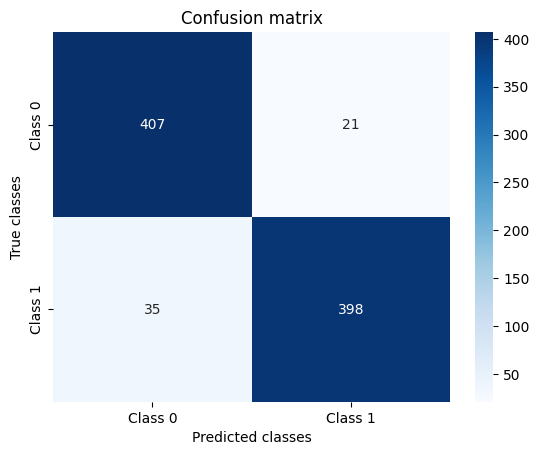

In [38]:
### CONFUSION MATRIX

plot_confusion_matrix(y_true=y_test, y_pred=y_pred_test)

#### **Plots**

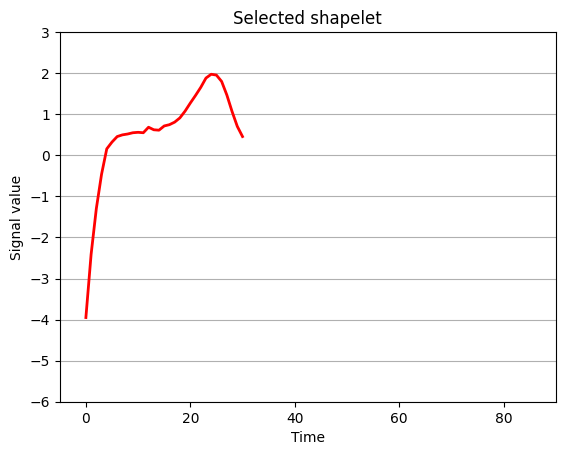

In [39]:
### SELECTED SHAPELET

plot_shapelet(shapelet_params=shapelet_params)

C:\Users\jules\AppData\Local\Temp\ipykernel_4264\2249425923.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class = int(predict(X_test=series, shapelet_params=shapelet_params))


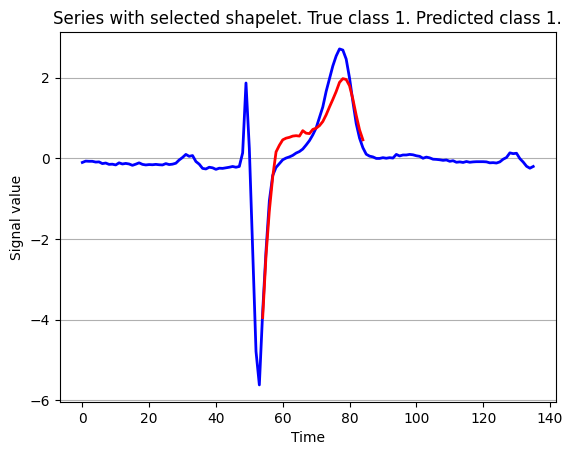

In [40]:
### PLOT SHAPELET ON A SERIES

SERIES_IDX = 111

plot_series_with_shapelet(
    X=X_test, y=y_test, shapelet_params=shapelet_params, index=SERIES_IDX
)

**Remarks :**

The algorithm is really fast to compute the 136 best shapelets (one of each size) and to select the best one, as training lasts around 15 seconds.

As there is randomness in the algorithm, the size of the selected shapelet can change between tries.

The accuracy on the test set can therefore vary a little bit, but is amlost always really good (between 92% and 99%).

### **Comparison with Bruteforce Shapelets**

In [41]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

X_train shape (23, 136)
X_test shape (861, 136)


In [47]:
### TRAINING TIME

# BRUTEFORCE SHAPELETS (FOR 1 SUBSEQUENCE LENGTH)

SUBSEQUENCE_LENGTH = 32
start_time = time.time()
bf_params = compute_bf_shapelets(
    X_train=X_train, y_train=y_train, subsequence_length=SUBSEQUENCE_LENGTH
)
end_time = time.time()
print(
    f"Bruteforce Shapelets for 1 subsequence length : {end_time-start_time:.2f} seconds"
)

# FAST SHAPELETS (FOR 136 SUBSEQUENCE LENGTHS)

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
start_time = time.time()
fs_params = compute_fast_shapelets_parallelized(
    X_train=X_train, y_train=y_train, params=PARAMS
)
end_time = time.time()
print(f"Fast Shapelets for 136 subsequence lengths : {end_time-start_time:.2f} seconds")

Bruteforce Shapelets for 1 subsequence length : 27.63 seconds
Fast Shapelets for 136 subsequence lengths : 13.79 seconds


In [48]:
### ACCURACIES

# BRUTEFORCE SHAPELETS (FOR 1 SUBSEQUENCE LENGTH)

find_classification_criterion(
    X_train=X_train, y_train=y_train, shapelet_params=bf_params
)
y_pred_bf_test = predict(X_test=X_test, shapelet_params=bf_params)
accuracy_bf_test = compute_accuracy(y_true=y_test, y_pred=y_pred_bf_test)
print(f"Bruteforce Shapelets accuracy on test set : {100*accuracy_bf_test:.2f} %")

# FAST SHAPELETS (FOR 136 SUBSEQUENCE LENGTHS)

find_classification_criterion(
    X_train=X_train, y_train=y_train, shapelet_params=fs_params
)
y_pred_fs_test = predict(X_test=X_test, shapelet_params=fs_params)
accuracy_fs_test = compute_accuracy(y_true=y_test, y_pred=y_pred_fs_test)
print(f"Fast Shapelets accuracy on test set : {100*accuracy_fs_test:.2f} %")

Bruteforce Shapelets accuracy on test set : 99.42 %
Fast Shapelets accuracy on test set : 94.77 %


**Remarks :**

Fast Shapelets is extremely fast compared to the bruteforce algorithm. It is twice as rapid as the bruteforce algorithm, but it computes 136 shapelets while the bruteforce algorithm computes only 1.

Here, the bruteforce algorithm has a better accuracy as the selected subsequence length is the optimal one (hte one that provides best results).

This shows that shapelet are more effective when knowing the desired length of the shapelet.

### **Comparison with 1 Nearest-Neighbor**

In [49]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

X_train shape (23, 136)
X_test shape (861, 136)


In [50]:
### TRAINING TIME

# 1 NEAREST NEIGHBOR

start_time = time.time()
knn = knn_train(X_train=X_train, y_train=y_train)
end_time = time.time()
print(f"1 Nearest Neighbor : {end_time-start_time:.2f} seconds")

# FAST SHAPELETS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
start_time = time.time()
fs_params = compute_fast_shapelets_parallelized(
    X_train=X_train, y_train=y_train, params=PARAMS
)
end_time = time.time()
print(f"Fast Shapelets for 136 subsequence lengths : {end_time-start_time:.2f} seconds")

1 Nearest Neighbor : 0.01 seconds
Fast Shapelets for 136 subsequence lengths : 13.64 seconds


In [51]:
### ACCURACIES

# 1 NEAREST NEIGHBOR

y_pred_knn_test = knn_predict(knn=knn, X_test=X_test)
accuracy_knn_test = compute_accuracy(y_true=y_test, y_pred=y_pred_knn_test)
print(f"1 Nearest Neighbor accuracy on test set : {100*accuracy_knn_test:.2f} %")

# FAST SHAPELETS

find_classification_criterion(
    X_train=X_train, y_train=y_train, shapelet_params=fs_params
)
y_pred_fs_test = predict(X_test=X_test, shapelet_params=fs_params)
accuracy_fs_test = compute_accuracy(y_true=y_test, y_pred=y_pred_fs_test)
print(f"Fast Shapelets accuracy on test set : {100*accuracy_fs_test:.2f} %")

1 Nearest Neighbor accuracy on test set : 79.67 %
Fast Shapelets accuracy on test set : 90.71 %


**Remarks :**

Though 1NN is extremely fast on this dataset, it does not provide the same results as Fast Shapelets.

Its accuracy is 80%.

### **DTW**

In [17]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

X_train shape (23, 136)
X_test shape (861, 136)


In [19]:
### TRAINING TIME

# FAST SHAPELETS (FOR 136 SUBSEQUENCE LENGTHS)

PARAMS = {
    "dimensionality": 16,
    "cardinality": 4,
    "r": 10,
    "k": 10,
    "proba": 0.8,
    "distance_method": "dtw",
}
start_time = time.time()
fs_params = compute_fast_shapelets_parallelized(
    X_train=X_train, y_train=y_train, params=PARAMS
)
end_time = time.time()
print(f"Fast Shapelets for 136 subsequence lengths : {end_time-start_time:.2f} seconds")

# BRUTEFORCE SHAPELETS (FOR 1 SUBSEQUENCE LENGTH)

SUBSEQUENCE_LENGTH = 32
start_time = time.time()
bf_params = compute_bf_shapelets(
    X_train=X_train, y_train=y_train, subsequence_length=SUBSEQUENCE_LENGTH
)
end_time = time.time()
print(
    f"Bruteforce Shapelets for 1 subsequence length : {end_time-start_time:.2f} seconds"
)

# 1 NEAREST NEIGHBOR

start_time = time.time()
knn = knn_train(X_train=X_train, y_train=y_train, distance_method="dtw")
end_time = time.time()
print(f"1 Nearest Neighbor : {end_time-start_time:.2f} seconds")

1 Nearest Neighbor : 0.00 seconds


In [ ]:
### ACCURACIES

# FAST SHAPELETS (FOR 136 SUBSEQUENCE LENGTHS)

find_classification_criterion(
    X_train=X_train, y_train=y_train, shapelet_params=fs_params
)
y_pred_fs_test = predict(X_test=X_test, shapelet_params=fs_params)
accuracy_fs_test = compute_accuracy(y_true=y_test, y_pred=y_pred_fs_test)
print(f"Fast Shapelets accuracy on test set : {100*accuracy_fs_test:.2f} %")

# BRUTEFORCE SHAPELETS (FOR 1 SUBSEQUENCE LENGTH)

find_classification_criterion(
    X_train=X_train, y_train=y_train, shapelet_params=bf_params
)
y_pred_bf_test = predict(X_test=X_test, shapelet_params=bf_params)
accuracy_bf_test = compute_accuracy(y_true=y_test, y_pred=y_pred_bf_test)
print(f"Bruteforce Shapelets accuracy on test set : {100*accuracy_bf_test:.2f} %")

# 1 NEAREST NEIGHBOR

y_pred_knn_test = knn_predict(knn=knn, X_test=X_test)
accuracy_knn_test = compute_accuracy(y_true=y_test, y_pred=y_pred_knn_test)
print(f"1 Nearest Neighbor accuracy on test set : {100*accuracy_knn_test:.2f} %")

**Remarks :**

Impossible to use as it is too long to run.

Fast Shapelets was not done running after 40 minutes.

### **Randomness**

In [21]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

X_TRAIN shape (23, 136)
X_TEST shape (861, 136)


In [22]:
### COMPUTE RANDOMNESS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
iterations, train_accuracies, test_accuracies = compute_randomness(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    nb_times=20,
)

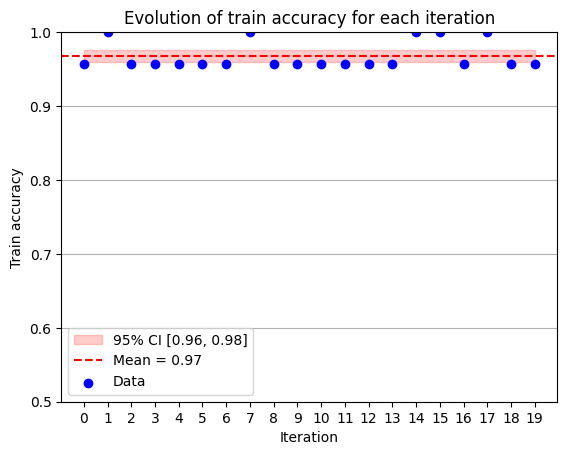

In [23]:
### PLOT : TRAIN ACCURACY

plot_results_randomness(
    iterations=iterations,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="train",
)

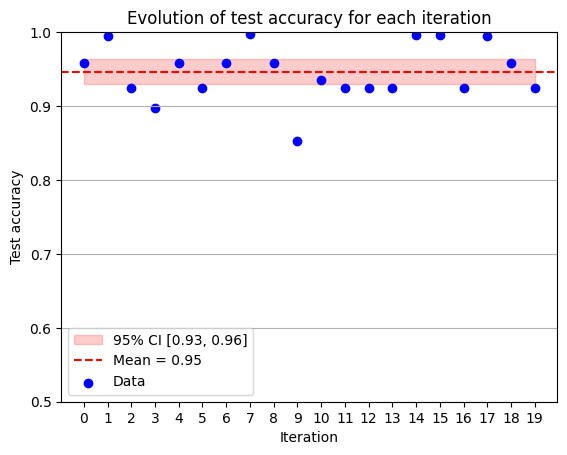

In [24]:
### PLOT : TEST ACCURACY

plot_results_randomness(
    iterations=iterations,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="test",
)

**Remarks :**

As there is randmness with the random projection, the selected shapelet can vary.

This can lead to a huge difference in performance.

This is something to keep in mind before using the algorithm.

### **Experiments on parameters**

#### **Dimensionality**

In [ ]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

In [6]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "dimensionality"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 20/20 [38:23<00:00, 115.20s/it]


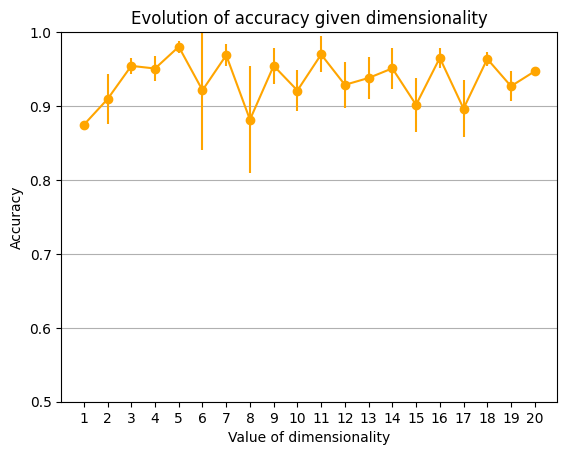

In [8]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

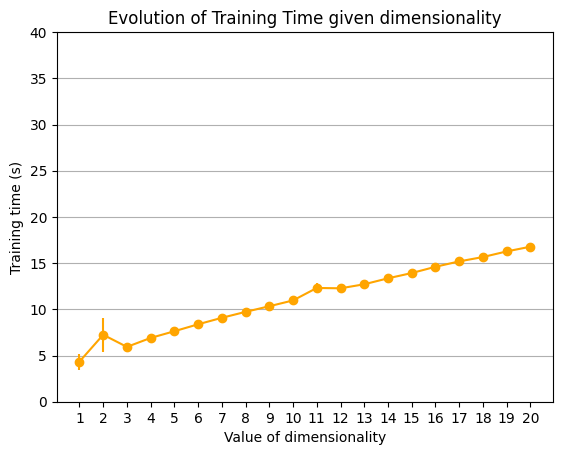

In [9]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="Training Time",
)

**Remarks :**

Dimensionality seems to be the key parameter of the algorithm.

For both accuracy and training time, this is the parameter that leads to the greatest changes.

#### **Cardinality**

In [ ]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

In [10]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "cardinality"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 20/20 [49:46<00:00, 149.33s/it]


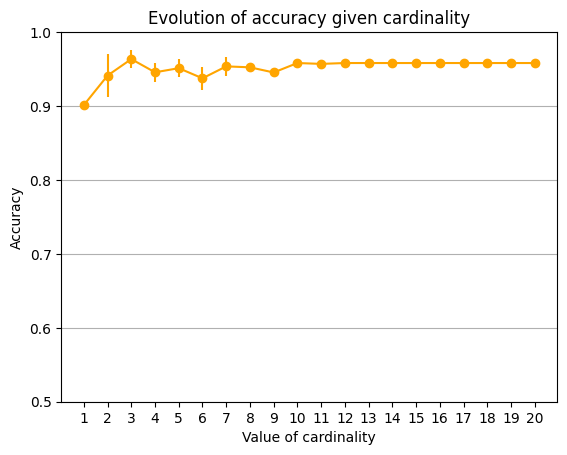

In [12]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

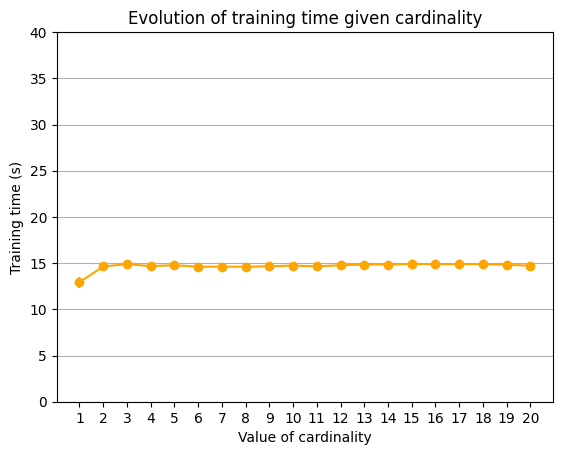

In [13]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)

**Remarks :**

As one could possibly guess, it is important not to set the cardinality too low, or it will be harder to distinguish different subsequences.

But except for this, this parameter does not affect much accuracy or training time.

#### **R**

In [ ]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

In [6]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "r"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 20/20 [49:56<00:00, 149.84s/it] 


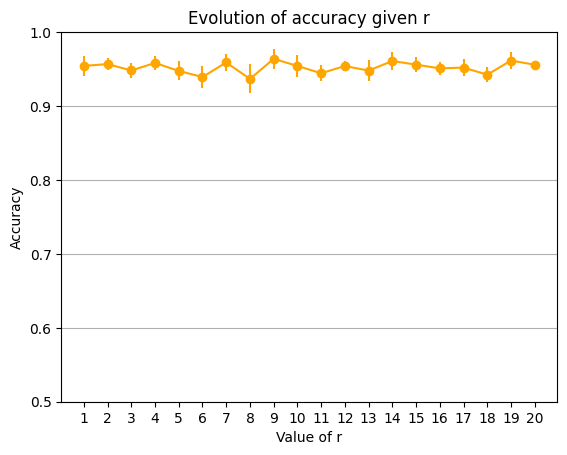

In [7]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

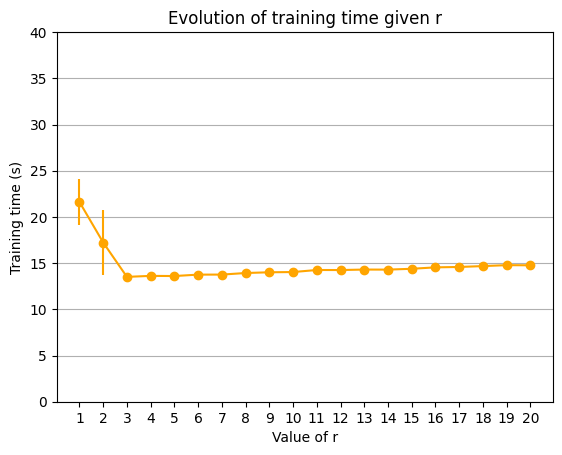

In [8]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)

**Remarks :**

As mentionned in the article, varying R does not change the accuracy.

It only affects slightly the training time (first occurencies might be due to the computer rather than the model).

#### **K**

In [ ]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

In [6]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "k"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 20/20 [49:48<00:00, 149.45s/it]


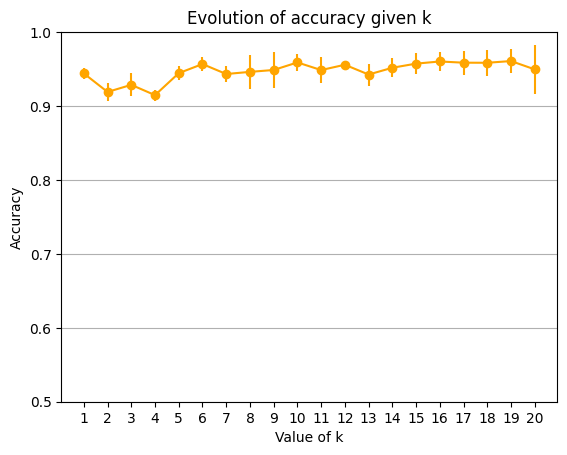

In [7]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

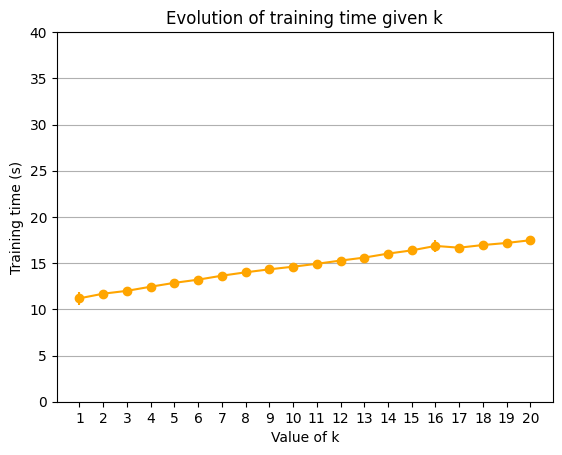

In [8]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)

**Remarks :**

As mentionned in the article, increasing *k* does not have a significant impact on the accuracy, but it increases the training time as expected.

#### **Proba : proba that a letter of the SAX representation appears**

In [ ]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

In [9]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "proba"
VALUES = np.linspace(start=0.1, stop=1, num=10)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 10/10 [24:32<00:00, 147.26s/it]


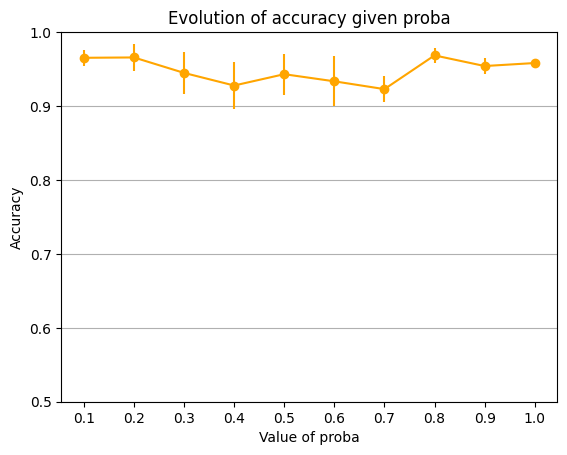

In [10]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

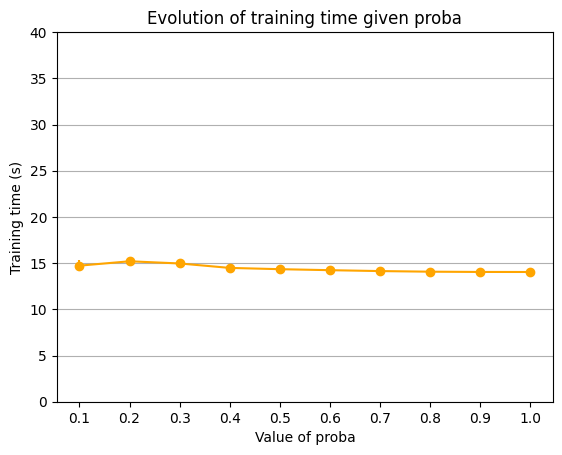

In [11]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)

**Remarks :**

As expected, the closer to 0.5 this parameter is, the more random the results are and the more variance there is regarding the accuracy.

As expected, it does not impact training time.

### **Noise in Data**

In [3]:
### SIGMAS

SIGMAS = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]

X_TRAIN shape (23, 136)
X_TEST shape (861, 136)


#### **Noise in test data only**

In [ ]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

In [4]:
### COMPUTE ACCURACIES

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
sigmas, knn_accuracies, shapelet_accuracies = compute_noise_accuracy(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    sigmas=SIGMAS,
    noise="test",
    nb_times=10,
)

100%|██████████| 9/9 [22:48<00:00, 152.02s/it]


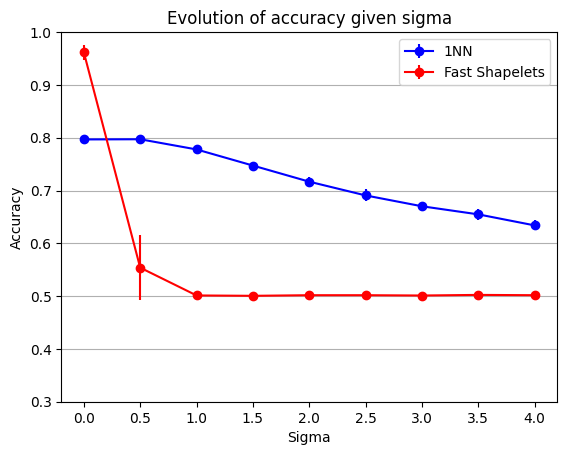

In [5]:
### PLOT : TEST ACCURACY

plot_results_noise(
    sigmas=SIGMAS,
    knn_accuracies=knn_accuracies,
    shapelet_accuracies=shapelet_accuracies,
)

**Remarks :**

Even though Fast Shapelets algorithm outperforms 1NN on "clean" data, the result is quite the opposite when we start adding noise to the test set.

Hence, 1NN might be more suited for real case scenarii with potential noise in the data.

#### **Noise in both train and test data**

In [ ]:
### DATA

X_train, y_train = load_data_from_hf("train")
X_test, y_test = load_data_from_hf("test")

In [6]:
### COMPUTE ACCURACIES

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
sigmas, knn_accuracies, shapelet_accuracies = compute_noise_accuracy(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    sigmas=SIGMAS,
    noise="both",
    nb_times=10,
)

100%|██████████| 9/9 [22:15<00:00, 148.41s/it]


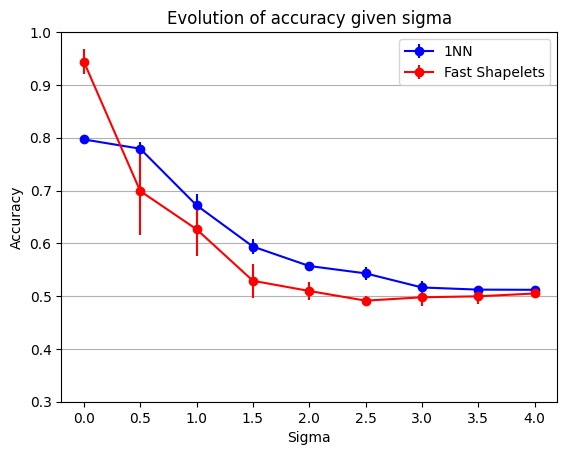

In [7]:
### PLOT : TEST ACCURACY

plot_results_noise(
    sigmas=SIGMAS,
    knn_accuracies=knn_accuracies,
    shapelet_accuracies=shapelet_accuracies,
)

**Remarks :**

When both train and test sets have noise, the two algorithms perform quite similarly, even though 1NN is slightly better.